In [2]:
import json
import stylia
import json
import os
import matplotlib.pyplot as plt
from scipy import interpolate
import numpy as np

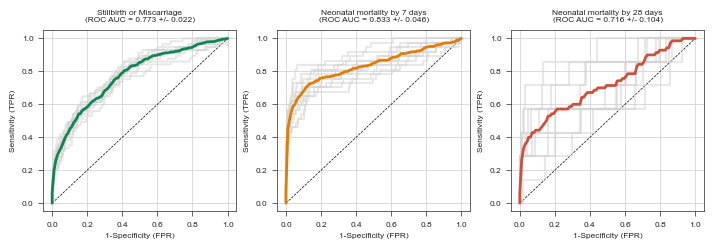

In [3]:
results_dir = "../results/"

points = ["cv_ml_d1_predelivery", "cv_ml_d2_earlydeath", "cv_ml_d3_latedeath"]

fig, axs = stylia.create_figure(1, 3, width=stylia.TWO_COLUMNS_WIDTH, height=stylia.TWO_COLUMNS_WIDTH/2.9)

titles = ["Stillbirth or Miscarriage", "Neonatal mortality by 7 days", "Neonatal mortality by 28 days"]

from stylia.colors.colors import NamedColors
colors = NamedColors()
colors = [colors.green, colors.orange, colors.red]


for i, point in enumerate(points):
    ax = axs.next()
    with open(os.path.join(results_dir, "tabpfn", point+".json")) as f:
        data = json.load(f)
    ax.plot([0,1], [0,1], lw = 0.5, color="black", ls="--")
    fprs = []
    tprs = []
    aurocs = []
    for d in data:
        fpr = d["fpr"]
        tpr = d["tpr"]
        ax.plot(fpr, tpr, lw=1.5, color="lightgrey", alpha=0.5)
        fprs += [fpr]
        tprs += [tpr]
        aurocs += [d["auroc"]]
    mean_fpr = np.linspace(0, 1, 100)
    interp_tprs = []
    for j in range(len(fprs)):
        interp_tpr = np.interp(mean_fpr, fprs[j], tprs[j])
        interp_tprs.append(interp_tpr)
    interp_tprs = np.array(interp_tprs)
    mean_tpr = [0] + list(np.mean(interp_tprs, axis=0))
    mean_fpr = [0] + list(mean_fpr)
    ax.plot(mean_fpr, mean_tpr, color=colors[i], lw=2)
    stylia.label(ax, title=titles[i] + "\n(ROC AUC = {0:.3f} +/- {1:.3f})".format(np.mean(aurocs), np.std(aurocs)), xlabel="1-Specificity (FPR)", ylabel="Sensitivity (TPR)")
    
plt.tight_layout()

stylia.save_figure("../assets/roc_tabpfn.png")
stylia.save_figure("../assets/roc_tabpfn.pdf")